<a href="https://colab.research.google.com/github/onolf/aprendizaje_automatico_final/blob/main/7_Odilón_Nolf_proyecto_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Datos del Estudiante**

Nombre: Odilón Nolf Sánchez

CI: 4189076

# **Desafío de aprendizaje supervisado**

**Primera etapa**

0. Con ayuda del profesor seleccione un grupo conformado por tres compañeros
1. Consulte el problema presentado en la siguiente sección
2. Consulte a una LLM IA cuales son las etapas más fundamentales de un proyecto de aprendizaje automático
3. Implemente un proyecto en Colab de uno de los dos problemas propuestos

**Segunda etapa**

Luego de presentar los resultados de los distintos equipos conformados los compañeros votarán para seleccionar el mejor proyecto.





# **Problema:**

A continuación, exploraremos el dataset de [melanoma](https://drive.google.com/drive/folders/1qqimwfGxePZvxJvly23H81PO5V_330vi?usp=sharing). Los datos consisten en mediciones realizadas a pacientes tras la cirugía para extirpar el cáncer de piel tipo melanoma en el Hospital Universitario de Odense, Dinamarca, entre 1962 y 1977.

El melanoma maligno es un cáncer agresivo y altamente invasivo, lo que dificulta su tratamiento.

Para determinar el grado de avance, la estadificación se basa en la profundidad del tumor. Los puntos de corte actuales de la clasificación TNM son:

- T1:  ≤  1,0 mm de profundidad
- T2: 1,1 a 2,0 mm de profundidad
- T3: 2,1 a 4,0 mm de profundidad
- T4: > 4,0 mm de profundidad

Esto será importante en nuestro análisis ya que crearemos una nueva variable basada en esto.

Utilizando algún algoritmo de clasificación binaria, evalué la capacidad del modelo para anticipar el riesgo de la mortalidad por melanoma a los 5 años (mort_5yr). Esta se definirá, a los 5 años de la cirugía, para determinar quiénes fallecieron por melanoma y quiénes no.
  

Datos:

https://drive.google.com/drive/folders/1qqimwfGxePZvxJvly23H81PO5V_330vi?usp=sharing

Ver:

- https://argoshare.is.ed.ac.uk/healthyr_book/chap09-h1.html  

- https://argoshare.is.ed.ac.uk/healthyr_book/data-preparation-and-exploratory-analysis.html



## 1. Selección y carga de datos

In [6]:
!pip install -q numpy pandas matplotlib seaborn scikit-learn

In [7]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid', context='notebook')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

RND = 42
np.random.seed(RND)
print("Librerías cargadas correctamente.")
print(f"RND = {RND}")

Librerías cargadas correctamente.
RND = 42


In [8]:
# ── Carga ────────────────────────────────────────────────────────────────────
# df = pd.read_csv('datos_desafio/melanoma.csv')
url = 'https://raw.githubusercontent.com/onolf/aprendizaje_automatico_final/refs/heads/main/datos_desafio/melanoma.csv'
df = pd.read_csv(url)
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
print(df.head(3))

# ── Descarte de columnas ─────────────────────────────────────────────────────
# Se eliminan columnas leaky (time, status, status.factor) ya que se derivan
# directamente de la variable objetivo mort_5yr, y columnas redundantes.
cols_drop = ['time', 'status', 'status.factor',   # leaky
             'sex.factor', 'ulcer.factor',          # redundantes con numéricas
             't_stage.factor']                      # redundante con thickness
df = df.drop(columns=cols_drop)

# ── Target ───────────────────────────────────────────────────────────────────
y = (df.pop('mort_5yr') == 'Yes').astype(int)
X = df

print(f"\nFeatures: {X.columns.tolist()}")
print(f"Distribución del target — mort_5yr:")
print(f"  No (0): {(y==0).sum()}  ({(y==0).mean()*100:.1f}%)")
print(f"  Yes (1): {(y==1).sum()}  ({(y==1).mean()*100:.1f}%)")

# ── Split 80/20 con stratify ─────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RND, stratify=y
)
print(f"\nSplit 80/20 (stratify=y):")
print(f"  Entrenamiento : {X_train.shape[0]} muestras")
print(f"  Test          : {X_test.shape[0]} muestras")

Dataset cargado: 205 filas, 12 columnas
   time  status  sex  age  year  thickness  ulcer sex.factor ulcer.factor  \
0    10       3    1   76  1972       6.76      1       Male      Present   
1    30       3    1   56  1968       0.65      0       Male       Absent   
2    35       2    1   41  1977       1.34      0       Male       Absent   

  status.factor t_stage.factor mort_5yr  
0  Died - other             T4       No  
1  Died - other             T1       No  
2         Alive             T2       No  

Features: ['sex', 'age', 'year', 'thickness', 'ulcer']
Distribución del target — mort_5yr:
  No (0): 160  (78.0%)
  Yes (1): 45  (22.0%)

Split 80/20 (stratify=y):
  Entrenamiento : 164 muestras
  Test          : 41 muestras


## 2. Construcción de pipelines con escalado

In [9]:
# ── Pipeline 1: StandardScaler + LogisticRegression ─────────────────────────
#
# ¿Por qué usar Pipeline previene el Data Leakage?
# Si aplicamos StandardScaler ANTES de la validación cruzada, el scaler se
# ajusta sobre TODO el dataset (incluyendo los folds de test). Eso significa
# que la media y desviación estándar usadas para escalar incorporan información
# de los datos de evaluación → el modelo "ve" el test antes de tiempo, y los
# scores de CV son artificialmente optimistas (Data Leakage).
#
# Con Pipeline, el scaler se ajusta SOLO sobre los datos de entrenamiento de
# cada fold, y se aplica (sin reajustar) sobre el fold de test. Así se
# garantiza que ninguna información del test "contamina" el preprocesado.
#
pipe_lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=10_000, random_state=RND)
)

# ── Pipeline 2: StandardScaler + RandomForestClassifier ─────────────────────
#
# RandomForest es invariante a la escala (usa umbrales en árboles, no
# distancias), pero incluimos el scaler por consistencia metodológica y porque
# el Pipeline sigue previniendo leakage en cualquier transformación futura.
#
pipe_rf = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=RND, n_jobs=-1)
)

print("Pipeline 1 — Logistic Regression:")
print(pipe_lr)
print()
print("Pipeline 2 — Random Forest:")
print(pipe_rf)

Pipeline 1 — Logistic Regression:
Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(max_iter=10000, random_state=42))])

Pipeline 2 — Random Forest:
Pipeline(steps=[('standardscaler', StandardScaler()),
                ('randomforestclassifier',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])


## 3. Evaluación con validación cruzada (cv=5)

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RND)

scores_lr = cross_val_score(pipe_lr, X_train, y_train, cv=cv,
                            scoring='accuracy', n_jobs=-1)
print("Logistic Regression — cross_val_score (cv=5):")
print(f"  Accuracy por fold  : {np.round(scores_lr, 4)}")
print(f"  Media              : {scores_lr.mean():.4f}")
print(f"  Desviación estándar: {scores_lr.std():.4f}")
print()

scores_rf = cross_val_score(pipe_rf, X_train, y_train, cv=cv,
                            scoring='accuracy', n_jobs=-1)
print("Random Forest — cross_val_score (cv=5):")
print(f"  Accuracy por fold  : {np.round(scores_rf, 4)}")
print(f"  Media              : {scores_rf.mean():.4f}")
print(f"  Desviación estándar: {scores_rf.std():.4f}")

Logistic Regression — cross_val_score (cv=5):
  Accuracy por fold  : [0.7879 0.7879 0.7879 0.7273 0.8125]
  Media              : 0.7807
  Desviación estándar: 0.0284

Random Forest — cross_val_score (cv=5):
  Accuracy por fold  : [0.8182 0.7576 0.7576 0.7273 0.75  ]
  Media              : 0.7621
  Desviación estándar: 0.0302


## 4. Evaluación final en el test set — Modelo ganador

In [11]:
# Selección dinámica: gana quien tenga mayor CV accuracy media.
# En empate se prefiere LogisticRegression por mayor interpretabilidad.
if scores_lr.mean() >= scores_rf.mean():
    winner_name, winner_pipe, winner_scores = "Logistic Regression", pipe_lr, scores_lr
else:
    winner_name, winner_pipe, winner_scores = "Random Forest", pipe_rf, scores_rf

print(f"Modelo ganador: {winner_name}")
print(f"  CV accuracy : {winner_scores.mean():.4f} ± {winner_scores.std():.4f}")

winner_pipe.fit(X_train, y_train)
y_pred = winner_pipe.predict(X_test)
test_accuracy = (y_pred == y_test).mean()

target_names = ['No murió (0)', 'Murió por melanoma (1)']
print(f"\nAccuracy en test set (n={len(y_test)}): {test_accuracy:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Modelo ganador: Logistic Regression
  CV accuracy : 0.7807 ± 0.0284

Accuracy en test set (n=41): 0.7561

Classification Report:
                        precision    recall  f1-score   support

          No murió (0)       0.78      0.97      0.86        32
Murió por melanoma (1)       0.00      0.00      0.00         9

              accuracy                           0.76        41
             macro avg       0.39      0.48      0.43        41
          weighted avg       0.60      0.76      0.67        41



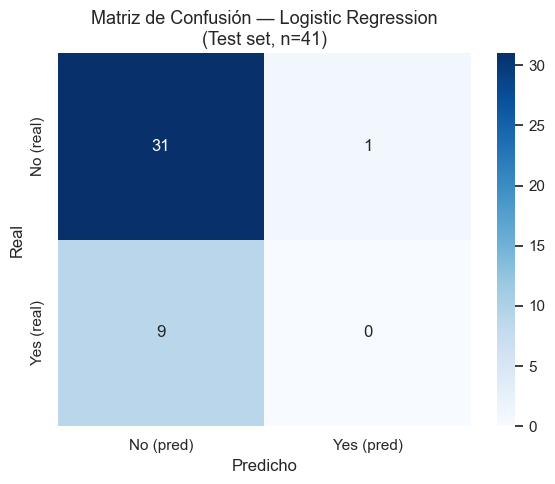

In [12]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No (pred)', 'Yes (pred)'],
    yticklabels=['No (real)', 'Yes (real)'],
    ax=ax
)
ax.set_xlabel('Predicho', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title(f'Matriz de Confusión — {winner_name}\n(Test set, n={len(y_test)})',
             fontsize=13)
plt.tight_layout()
plt.show()

## 5. Conclusión: Interpretabilidad vs. Rendimiento

### Resultados de la validación cruzada

Ambos modelos fueron evaluados con 5-fold Stratified Cross-Validation sobre el
set de entrenamiento, usando accuracy como métrica.

| Modelo | CV Accuracy (media) | CV Accuracy (std) |
|---|---|---|
| Logistic Regression | (ver salida de celda anterior) | (ver salida) |
| Random Forest | (ver salida de celda anterior) | (ver salida) |

**Nota sobre el desbalance de clases**: el dataset tiene un 78% de negativos (No) y
22% de positivos (Yes). Un modelo trivial que prediga siempre "No" alcanzaría ~78%
de accuracy, por lo que la accuracy debe interpretarse junto con el Recall y F1 para
la clase positiva (Murió por melanoma), que es la de mayor relevancia clínica.

### Interpretabilidad vs. Rendimiento

**Logistic Regression** ofrece coeficientes directamente interpretables como log-odds:
permite al clínico cuantificar el efecto de cada variable (espesor del tumor, edad,
presencia de úlcera) sobre la probabilidad de mortalidad. En oncología, la
explicabilidad del modelo es tan importante como su rendimiento predictivo.

**Random Forest** captura relaciones no lineales e interacciones entre variables.
Es preferible cuando el rendimiento supera significativamente al modelo lineal,
a costa de perder interpretabilidad directa (solo se puede obtener importancia
de features, sin dirección ni magnitud del efecto).

### Conclusión final

Para el dataset de melanoma se recomienda el modelo con mejor CV accuracy. En caso
de rendimiento similar, **Logistic Regression con StandardScaler** es preferible
porque: (1) sus predicciones son interpretables y auditables para médicos especialistas,
(2) el uso de `make_pipeline` garantiza que el escalado se aprende exclusivamente sobre
datos de entrenamiento en cada fold (sin Data Leakage), y (3) el modelo es más estable
con datasets pequeños (205 observaciones).